# Семинар 6 - Детекция

Будем использовать датасет VOC-2012:
http://host.robots.ox.ac.uk/pascal/VOC/
```
20 classes. The train/val data has 11,530 images containing 27,450 ROI annotated objects and 6,929 segmentations.
```

Классы:
```
{'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'}
```

# Инференс SSD

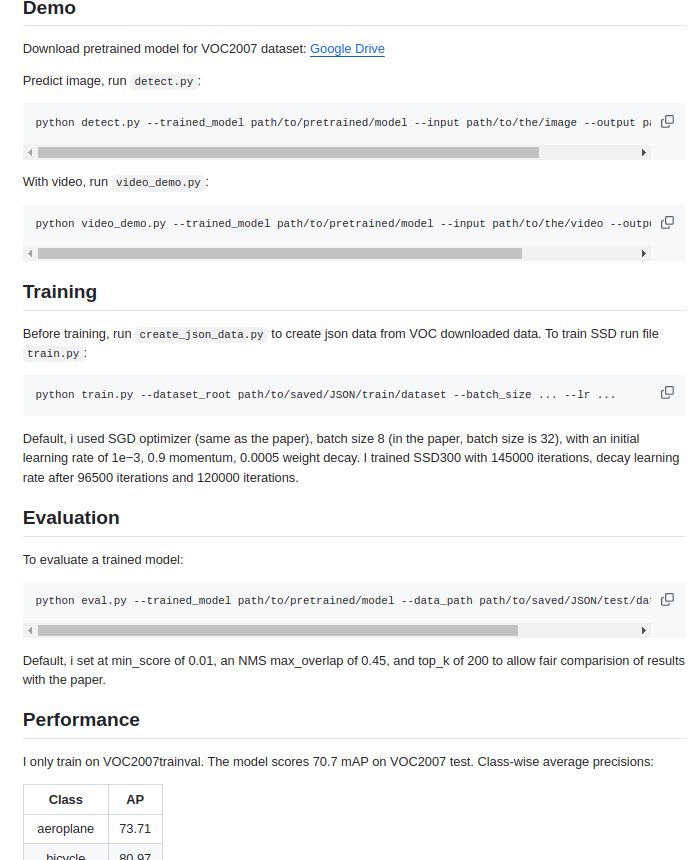

In [41]:
from IPython.display import Image
Image(filename='repo_screen.png') 

In [29]:
import sys
sys.path.append("./model/")
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from utils import *
from torchvision import transforms
import torch
from model.SSD300 import SSD300
from model.vgg import VGG16BaseNet, AuxiliaryNet, PredictionNet
import argparse

import warnings
warnings.filterwarnings("ignore")

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [31]:
img_path = './images/image_example4.jpg'
output_path = './out/image_example_with_detections4.jpg'

trained_model_path = './model_state_ssd300.pth.tar'

In [32]:
trained_model = torch.load(trained_model_path)
start_epoch = trained_model["epoch"] + 1
print('\nLoaded model trained with epoch %d.\n' % start_epoch)


Loaded model trained with epoch 231.



In [34]:
model = trained_model['model']
model = model.to(device)
model.eval()

resize = transforms.Resize((300, 300))
to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

In [35]:
def detect(model, device, original_image, min_score=0.4, max_overlap=0.45, top_k=200, suppress=None):
    
    image = normalize(to_tensor(resize(original_image)))
    image = image.to(device)
    
     # добавляем размерность, чтобы модель принимала на вход батч (1, C, H, W)
    locs_pred, cls_pred = model(image.unsqueeze(0))  
    detect_boxes, detect_labels, detect_scores = model.detect(locs_pred, cls_pred, 
                                                              min_score, max_overlap, top_k)
    detect_boxes = detect_boxes[0].to('cpu')
    
    # масштабируем изображение в батче в размеры оригинального изображения
    original_dims = torch.FloatTensor(
            [original_image.width, original_image.height, original_image.width, 
             original_image.height]).unsqueeze(0)
    
    detect_boxes = detect_boxes * original_dims
    
    # переводим числовые метки в текстовые
    detect_labels = [rev_label_map[l] for l in detect_labels[0].to('cpu').tolist()]
    
    if detect_labels == ["background"]:
        return original_image
    
    annotated_image = original_image
    draw = ImageDraw.Draw(annotated_image)
    font = ImageFont.load_default()
    
    for i in range(detect_boxes.size(0)):
        if suppress is not None:
            if detect_labels[i] in suppress:
                continue
    
        box_location = detect_boxes[i].tolist()
        draw.rectangle(xy=box_location, outline=label_color_map[detect_labels[i]])
        draw.rectangle(xy=[l + 1. for l in box_location])
        
        text_size = font.getsize(detect_labels[i].upper())
        text_location = [box_location[0] + 2., box_location[1] - text_size[1]]
        textbox_location = [box_location[0], box_location[1] - text_size[1], box_location[0] + text_size[0] + 4.,
                            box_location[1]]
        draw.rectangle(xy=textbox_location)
        draw.text(xy=text_location, text=detect_labels[i].upper(), fill='white', font=font)
    
    print("Detect label: ", detect_labels)
    return annotated_image

Detect label:  ['cow']


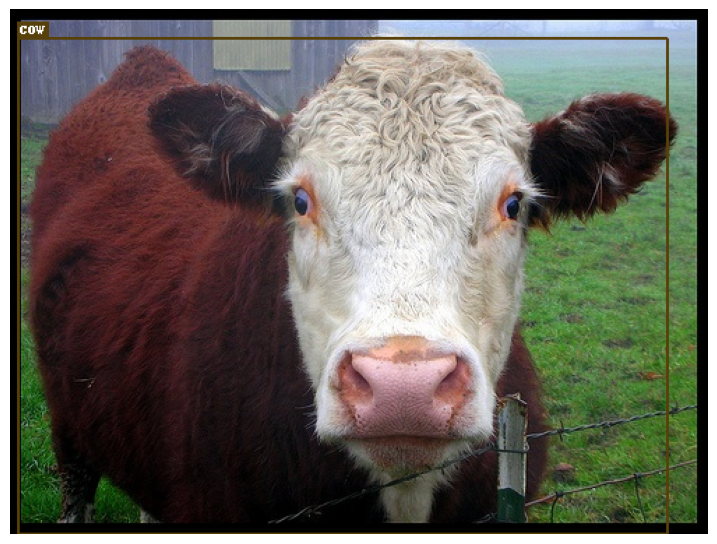

In [36]:
original_image = Image.open(img_path, mode='r')
original_image = original_image.convert('RGB')
annotated_image = detect(model, device, original_image)

plt.figure(figsize=(9,9))
plt.axis('off')
plt.imshow(annotated_image)

# Обучение

In [1]:
import sys
sys.path.append("./model/")
import torch
import torch.backends.cudnn as cudnn
import torch.optim as optim
from model.SSD300 import SSD300
from model.vgg import VGG16BaseNet, AuxiliaryNet, PredictionNet
from model.mutibox_loss import MultiBoxLoss
from datasets import VOCDataset
from utils import *
from model.metrics.metric import Metrics
import argparse
from create_json_data import create_json_data

Форматируем датасет PascalVOC под json: 

In [2]:
create_json_data('./../VOC/voc_2007_2012/VOC2007/', './JSONdata')

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
data_folder = './JSONdata'
num_classes = len(label_map)
checkpoint = None
batch_size = 4
iterations = 145000   # кол-во итераций для обучения
workers = 4
print_freq = 100   # распечатывать логи от обучения каждые print_freq батчей
lr = 1e-3
decay_lr_at = [96500, 120000]  # decay learning rate after these many iterations
decay_lr_to = 0.1  # decay learning rate to this fraction of the existing learning rate
momentum = 0.9   # Momentum value for optim
weight_decay = 5e-4   # weight decay for SGD
cudnn.benchmark = True
epochs = 20

In [5]:
def train(train_loader, model, criterion, optimizer, epoch):
    '''
        One epoch's training
    '''
    model.train()
    losses = Metrics()
    
    for i, (images, boxes, labels, _) in enumerate(train_loader):
        
        images = images.to(device)  # (batch_size (N), 3, 300, 300)
        boxes = [b.to(device) for b in boxes]
        labels = [l.to(device) for l in labels]
        
        # Foward pass
        locs_pred, cls_pred = model(images)
        
        # Loss
        loss = criterion(locs_pred, cls_pred, boxes, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
            
        optimizer.step()
        losses.update(loss.item(), images.size(0))
        
        if i % print_freq == 0:
            print('Epoch: [{0}][{1}/{2}]\t' 'Loss {loss.val:.4f} ( Average Loss per epoch: {loss.avg:.4f})\t'.format(epoch, i, len(train_loader), loss=losses))
    del locs_pred, cls_pred, images, boxes, labels

In [6]:
def save_checkpoint(epoch, model, optimizer):
    '''
        Save model checkpoint
    '''
    state = {'epoch': epoch, "model": model, "optimizer": optimizer}
    filename = "model_state_ssd300_.pth.tar"
    torch.save(state, filename)

In [7]:
global start_epoch, label_map, epoch, checkpoint, decay_lr_at

#Init model or load checkpoint
if checkpoint is None:
    start_epoch = 0
    model = SSD300(num_classes)
    optimizer = optim.SGD(lr = lr, momentum=momentum, weight_decay=weight_decay)
else:
    checkpoint = torch.load(checkpoint)
    start_epoch = checkpoint['epoch'] + 1   
    print('\nLoaded checkpoint from epoch %d.\n' % start_epoch)
    model = checkpoint['model']
    optimizer = checkpoint['optimizer']

#Move to default device
model = model.to(device)
criterion = MultiBoxLoss(model.default_boxes).to(device)

train_dataset = VOCDataset(data_folder, split= "train")
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, 
                                           shuffle= True, collate_fn = combine,
                                           num_workers = workers, pin_memory = True)

decay_lr_at = [it // (len(train_dataset) // batch_size) for it in decay_lr_at]

for epoch in range(start_epoch, epochs):
    if epoch in decay_lr_at:
        print("Decay learning rate...")
        adjust_lr(optimizer, decay_lr_to)

    train(train_loader = train_loader, model = model, criterion = criterion,
          optimizer = optimizer, epoch = epoch)

    save_checkpoint(epoch, model, optimizer)

Loading pretrained base model...
Loaded base model
Epoch: [0][0/1253]	Loss 22.7731 ( Average Loss per epoch: 22.7731)	
Epoch: [0][100/1253]	Loss 11.4005 ( Average Loss per epoch: 13.6356)	
Epoch: [0][200/1253]	Loss 7.3384 ( Average Loss per epoch: 12.2783)	
Epoch: [0][300/1253]	Loss 12.8946 ( Average Loss per epoch: 11.1953)	
Epoch: [0][400/1253]	Loss 6.1121 ( Average Loss per epoch: 10.6841)	
Epoch: [0][500/1253]	Loss 13.5890 ( Average Loss per epoch: 10.1889)	
Epoch: [0][600/1253]	Loss 21.9663 ( Average Loss per epoch: 10.1239)	
Epoch: [0][700/1253]	Loss 12.3753 ( Average Loss per epoch: 10.1647)	
Epoch: [0][800/1253]	Loss 11.4890 ( Average Loss per epoch: 10.1258)	
Epoch: [0][900/1253]	Loss 5.9827 ( Average Loss per epoch: 10.0456)	
Epoch: [0][1000/1253]	Loss 6.2339 ( Average Loss per epoch: 10.0924)	
Epoch: [0][1100/1253]	Loss 5.8096 ( Average Loss per epoch: 10.2455)	
Epoch: [0][1200/1253]	Loss 6.4606 ( Average Loss per epoch: 10.0412)	
Epoch: [1][0/1253]	Loss 5.7771 ( Average Los

# Валидация

In [19]:
trained_model = torch.load('./model_state_ssd300_.pth.tar')
model = trained_model["model"]
model = model.to(device)

In [25]:
model.eval();   # Set eval model

In [21]:
#Load test dataset
test_dataset = VOCDataset(data_folder, split = "TEST")
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, 
                                          shuffle = False, collate_fn = combine, 
                                          num_workers = workers, pin_memory = True)

In [24]:
def evaluate(model, test_loader, min_score=0.4, max_overlap=0.45, top_k=200):
    '''
        Evaluate model by caculate mAP
        model: model SSD
        test_loader: Dataloader for test data
        
        Out: mAP for test data
    '''
    
    model.eval()
    
    detect_boxes = []
    detect_labels = []
    detect_scores = []
    t_boxes = []
    t_labels = []
    t_difficulties = []
    with torch.no_grad():
        for i, (images, boxes, labels, difficulties) in enumerate(tqdm(test_loader, desc = "Evaluating")):
            images = images.to(device)
            
            locs_pred, cls_pred = model(images)
            detect_boxes_batch, detect_labels_batch, detect_score_batch = model.detect(locs_pred, 
                                                                                       cls_pred,
                                                                                       min_score = min_score,
                                                                                       max_overlap = max_overlap,
                                                                                       top_k = top_k)
            boxes = [b.to(device) for b in boxes]
            labels = [l.to(device) for l in labels]
            difficulties = [d.to(device) for d in difficulties]
            
            detect_boxes.extend(detect_boxes_batch)
            detect_labels.extend(detect_labels_batch)
            detect_scores.extend(detect_score_batch)
            t_boxes.extend(boxes)
            t_labels.extend(labels)
            t_difficulties.extend(difficulties)
        
        APs, mAP = calculate_mAP(detect_boxes, detect_labels, detect_scores, t_boxes, t_labels, t_difficulties)
        
    print(APs)
    print("Mean Average Precision (mAP): %.3f" % mAP)
    
    

evaluate(model, test_loader)

Evaluating: 100%|███████████████████████████████| 78/78 [00:57<00:00,  1.36it/s]


{'aeroplane': 0.5761604905128479, 'bicycle': 0.4368647038936615, 'bird': 0.3388976752758026, 'boat': 0.17802254855632782, 'bottle': 0.13368983566761017, 'bus': 0.4562203884124756, 'car': 0.5386862754821777, 'cat': 0.437570720911026, 'chair': 0.09090909361839294, 'cow': 0.30287301540374756, 'diningtable': 0.0363636389374733, 'dog': 0.4148905277252197, 'horse': 0.5974568128585815, 'motorbike': 0.5203495025634766, 'person': 0.4877040386199951, 'pottedplant': 0.05681818351149559, 'sheep': 0.3810168206691742, 'sofa': 0.24546372890472412, 'train': 0.5870380401611328, 'tvmonitor': 0.5056239366531372}
Mean Average Precision (mAP): 0.366
